 # Importing all the necessary Libraries

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec


In [13]:
CSV_PATH = r"C:\Users\ask1315\Downloads\mlproject\creditcard_2023.csv"
print(f"Loading from: {CSV_PATH}")


Loading from: C:\Users\ask1315\Downloads\mlproject\creditcard_2023.csv


#Loading the Data

In [14]:
data = pd.read_csv(CSV_PATH)
print(f"Dataset shape: {data.shape}")
print(f"Columns: {list(data.columns)}")
data.head()


Dataset shape: (568630, 31)
Columns: ['id', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0


#Understanding the Data

In [15]:
print(data.describe())

                  id            V1            V2            V3            V4  \
count  568630.000000  5.686300e+05  5.686300e+05  5.686300e+05  5.686300e+05   
mean   284314.500000 -5.638058e-17 -1.319545e-16 -3.518788e-17 -2.879008e-17   
std    164149.486121  1.000001e+00  1.000001e+00  1.000001e+00  1.000001e+00   
min         0.000000 -3.495584e+00 -4.996657e+01 -3.183760e+00 -4.951222e+00   
25%    142157.250000 -5.652859e-01 -4.866777e-01 -6.492987e-01 -6.560203e-01   
50%    284314.500000 -9.363846e-02 -1.358939e-01  3.528579e-04 -7.376152e-02   
75%    426471.750000  8.326582e-01  3.435552e-01  6.285380e-01  7.070047e-01   
max    568629.000000  2.229046e+00  4.361865e+00  1.412583e+01  3.201536e+00   

                 V5            V6            V7            V8            V9  \
count  5.686300e+05  5.686300e+05  5.686300e+05  5.686300e+05  5.686300e+05   
mean   7.997245e-18 -3.958636e-17 -3.198898e-17  2.109273e-17  3.998623e-17   
std    1.000001e+00  1.000001e+00  1.00000

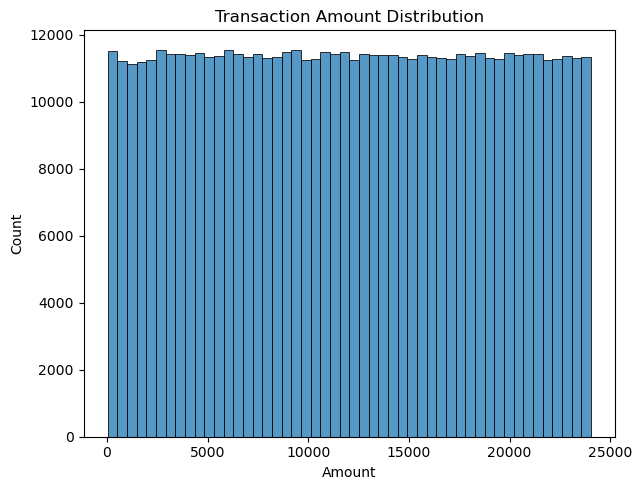

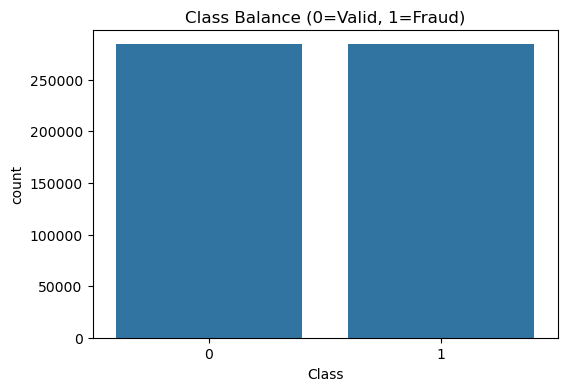

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Remove possible spaces in column names
data.columns = data.columns.str.strip()

# Quick visualizations
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(data['Amount'], bins=50)
plt.title('Transaction Amount Distribution')

# Only run if Time exists
if 'Time' in data.columns:
    plt.subplot(1,2,2)
    sns.histplot(data['Time'], bins=50)
    plt.title('Transaction Time Distribution')

plt.tight_layout()
plt.show()


# Plot class balance
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=data)
plt.title('Class Balance (0=Valid, 1=Fraud)')
plt.show()


# Scatter sample
sample = data.sample(n=min(5000, len(data)), random_state=42)

if 'Time' in data.columns:
    plt.figure(figsize=(8,6))
    sns.scatterplot(x='Time', y='Amount', hue='Class', data=sample, alpha=0.5)
    plt.title('Time vs Amount (sample)')
    plt.show()

#Describing the Data

#Imbalance in the data

In [17]:
fraud = data[data['Class'] == 1]
valid = data[data['Class'] == 0]
outlierFraction = len(fraud)/float(len(valid))
print(outlierFraction)
print('Fraud Cases: {}'.format(len(data[data['Class'] == 1])))
print('Valid Transactions: {}'.format(len(data[data['Class'] == 0])))

1.0
Fraud Cases: 284315
Valid Transactions: 284315


#Print the amount details for Fraudulent Transaction

In [18]:
print("Amount details of the fraudulent transaction")
fraud.Amount.describe()

Amount details of the fraudulent transaction


count    284315.000000
mean      12057.601763
std        6909.750891
min          50.010000
25%        6074.640000
50%       12062.450000
75%       18033.780000
max       24039.930000
Name: Amount, dtype: float64

# Print the amount details for Normal Transaction

In [19]:
print("details of valid transaction")
valid.Amount.describe()

details of valid transaction


count    284315.000000
mean      12026.313506
std        6929.500715
min          50.120000
25%        6034.540000
50%       11996.900000
75%       18040.265000
max       24039.930000
Name: Amount, dtype: float64

#Plotting the Correlation Matrix

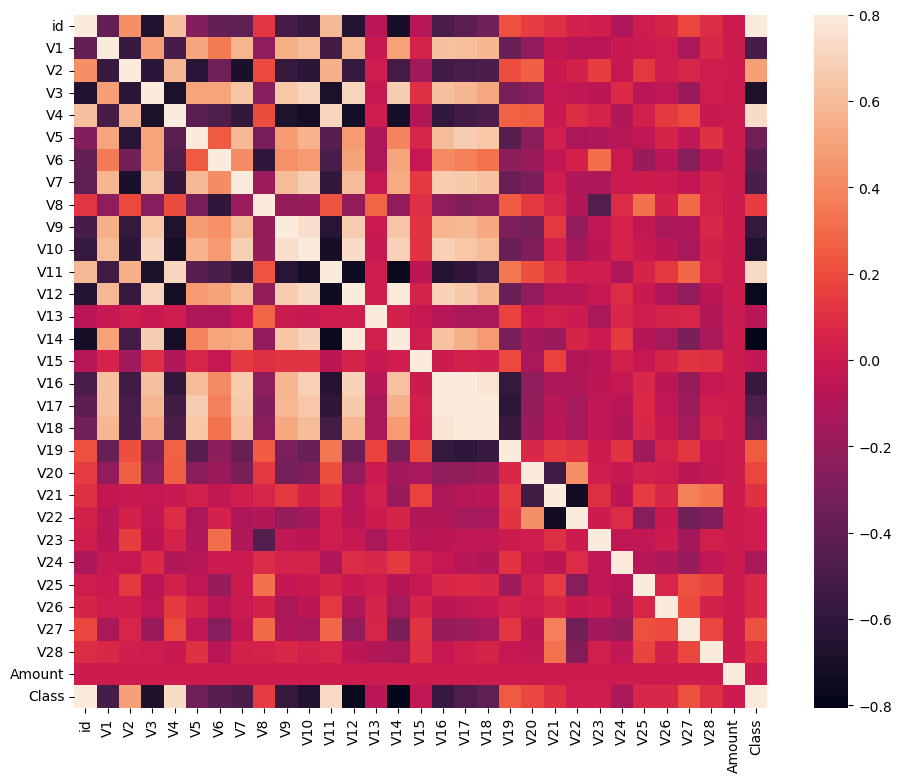

In [20]:
corrmat = data.corr(numeric_only=True)
fig = plt.figure(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True)
plt.show()


#Separating the X and the Y values

In [21]:
# dividing the X and the Y from the dataset
X = data.drop(['Class'], axis = 1)
Y = data["Class"]
print(X.shape)
print(Y.shape)
# getting just the values for the sake of processing
# (its a numpy array with no columns)
xData = X.values
yData = Y.values

(568630, 30)
(568630,)


#Training and Testing Data Bifurcation

In [22]:
# Using Scikit-learn to split data into training and testing sets
from sklearn.model_selection import train_test_split
# Split the data into training and testing sets
xTrain, xTest, yTrain, yTest = train_test_split(
        xData, yData, test_size = 0.2, random_state = 42)


#Building a Random Forest Model using scikit learn

In [23]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier()
rfc.fit(xTrain, yTrain)
# predictions
yPred = rfc.predict(xTest)

In [24]:
# Hyperparameter tuning and model refinement
# utilize GridSearchCV to find optimal parameters for the RandomForest
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced', None]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid.fit(xTrain, yTrain)
print("Best parameters found:", grid.best_params_)

# replace the classifier with the tuned version
rfc = grid.best_estimator_
# re-generate predictions with the tuned model

yPred = rfc.predict(xTest)


Fitting 3 folds for each of 24 candidates, totalling 72 fits


KeyboardInterrupt: 

In [ ]:
from sklearn.impute import SimpleImputer
print("NaN values in yTest before imputation:", np.isnan(yTest).sum())

imputer = SimpleImputer(strategy='most_frequent')
yTest = imputer.fit_transform(yTest.reshape(-1, 1)).flatten()
print("NaN values in yTest after imputation:", np.isnan(yTest).sum())

#evaluating parameters

In [ ]:
# Evaluating the classifier
# printing every score of the classifier
# scoring in anything
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score, matthews_corrcoef
from sklearn.metrics import confusion_matrix

n_outliers = len(fraud)
n_errors = (yPred != yTest).sum()
print("The model used is Random Forest classifier")

acc = accuracy_score(yTest, yPred)
print("The accuracy is {}".format(acc))

prec = precision_score(yTest, yPred)
print("The precision is {}".format(prec))

rec = recall_score(yTest, yPred)
print("The recall is {}".format(rec))

f1 = f1_score(yTest, yPred)
print("The F1-Score is {}".format(f1))

MCC = matthews_corrcoef(yTest, yPred)
print("The Matthews correlation coefficient is{}".format(MCC))

#Visualizing the Confusion Matrix

In [ ]:
# printing the confusion matrix
LABELS = ['Normal', 'Fraud']
conf_matrix = confusion_matrix(yTest, yPred)
plt.figure(figsize =(12, 12))
sns.heatmap(conf_matrix, xticklabels = LABELS,
            yticklabels = LABELS, annot = True, fmt ="d");
plt.title("Confusion matrix")
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.show()

In [ ]:
### Feature importance and probability threshold tuning

# examine which variables contribute most to the RandomForest decisions
importances = rfc.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Feature importances")
plt.bar(range(X.shape[1]), importances[indices], align='center')
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.tight_layout()
plt.show()

# probabilities and adjusting decision threshold
probs = rfc.predict_proba(xTest)[:,1]
for thresh in [0.3, 0.5, 0.7]:
    yPred_thresh = (probs > thresh).astype(int)
    acc_t = accuracy_score(yTest, yPred_thresh)
    f1_t = f1_score(yTest, yPred_thresh)
    print(f"Threshold {thresh}: accuracy={acc_t:.4f}, f1={f1_t:.4f}")


In [ ]:
# Additional class-wise visualization

# KDE plots for selected features by class
plt.figure(figsize=(12,5))
for i, feat in enumerate(['Amount','Time']):
    plt.subplot(1,2,i+1)
    sns.kdeplot(data=data, x=feat, hue='Class', fill=True, common_norm=False, alpha=0.5)
    plt.title(f'{feat} distribution by class')
plt.tight_layout()
plt.show()

# t-SNE projection of a small sample
from sklearn.manifold import TSNE
sample = data.sample(n=min(2000, len(data)), random_state=42)
features = sample.drop('Class', axis=1)
labels = sample['Class']

tsne = TSNE(n_components=2, random_state=42, perplexity=40, n_iter=300)
emb = tsne.fit_transform(features)

plt.figure(figsize=(8,6))
sns.scatterplot(x=emb[:,0], y=emb[:,1], hue=labels, palette='coolwarm', alpha=0.6)
plt.title('t-SNE projection of transactions (fraud vs. valid)')
plt.show()
